# ITSM / Customer Support Ticket Routing — Multi-task NLP

**Датасет:** `Tobi-Bueck/customer-support-tickets` (61 765 строк, EN/DE)  
**Задача:** мультиклассовая классификация по трём таргетам  
**Метрика:** `Score = 0.70·MacroF1(queue) + 0.15·Acc(priority) + 0.15·Acc(type)`

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import joblib
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report

plt.rcParams.update({'figure.dpi': 150, 'font.size': 10})
sns.set_theme(style='whitegrid', palette='tab10')

REPO = Path('.')
PLOTS = REPO / 'plots'
MODELS = REPO / 'models'

print('Setup OK')

Setup OK


---
## 1. Введение и постановка задачи

**Цель:** построить pipeline маршрутизации тикетов поддержки, предсказывающий одновременно:

| Таргет | Классов | Вес в Score |
|--------|---------|-------------|
| `queue` | 52 | 0.70 · Macro-F1 |
| `priority` | 5 | 0.15 · Accuracy |
| `type` | 5 + Unknown | 0.15 · Accuracy |

**Вход:** `subject + ' [SEP] ' + body` (EN/DE, смешанный язык)  
**Фиксированный split:** seed=42, train=49 412 / val=6 176 / test=6 177  
**Без пересечений текстов** между сплитами.

### Исследованные методы
1. **TF-IDF + LinearSVC** — быстрый интерпретируемый baseline  
2. **DistilBERT Multi-task Fine-tuning** — joint обучение трёх голов  
3. **KNN + Sentence-Transformers** — поиск ближайших соседей в embedding-пространстве  
4. **Hybrid KNN+TF-IDF** — смешивание скоров для улучшения recall  
5. **Confidence Analysis** — метрика «уверенности» модели

---
## 2. Данные и EDA

In [2]:
print('Загружаем датасет с HuggingFace...')
ds = load_dataset('Tobi-Bueck/customer-support-tickets')['train']
df = ds.to_pandas()
df['type'] = df['type'].fillna('Unknown')

def read_idx(path):
    return np.loadtxt(path, dtype=np.int64)

splits = {}
for name in ('train', 'val', 'test'):
    idx = read_idx(REPO / 'data' / f'{name}_idx.txt')
    splits[name] = df.iloc[idx].reset_index(drop=True).copy()

for name, d in splits.items():
    d['type'] = d['type'].fillna('Unknown')

print(f'Датасет: {len(df):,} строк × {df.shape[1]} колонок')
print('Сплиты:')
for name, d in splits.items():
    print(f'  {name}: {len(d):,}')

Загружаем датасет с HuggingFace...


Датасет: 61,765 строк × 16 колонок
Сплиты:
  train: 49,412
  val: 6,176
  test: 6,177


### 2.1 Распределение классов `queue`

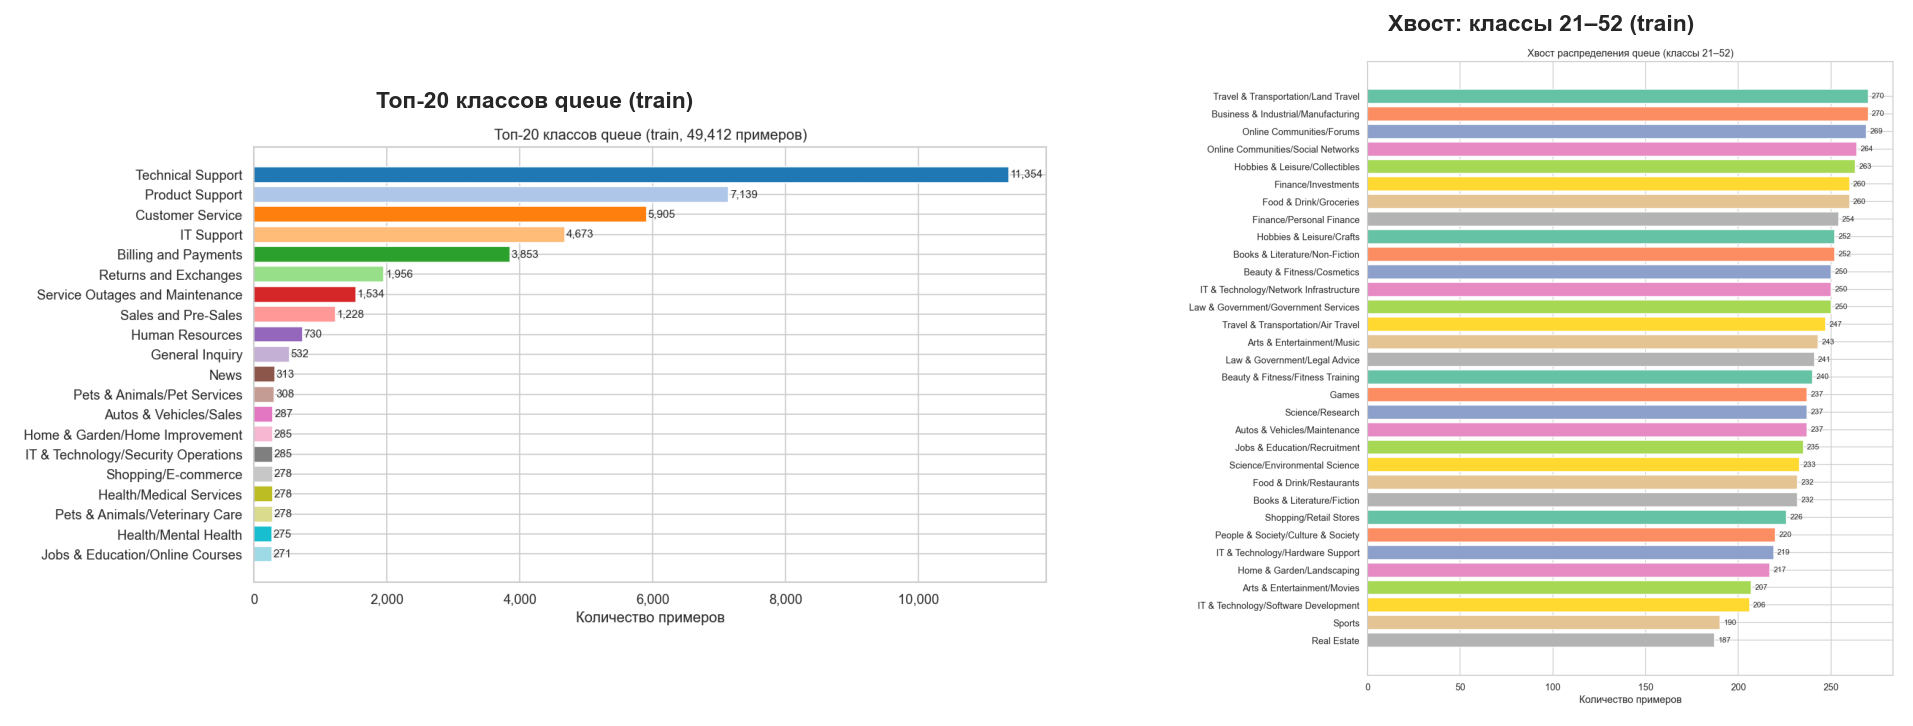

Классов queue: 52
Max/Min ratio: 61x  (от 187 до 11,354)
Топ-3: [('Technical Support', 11354), ('Product Support', 7139), ('Customer Service', 5905)]


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Топ-20 классов
img1 = mpimg.imread(PLOTS / 'queue_top20.png')
axes[0].imshow(img1)
axes[0].axis('off')
axes[0].set_title('Топ-20 классов queue (train)', fontsize=11, fontweight='bold')

# Хвост распределения
img2 = mpimg.imread(PLOTS / 'queue_tail.png')
axes[1].imshow(img2)
axes[1].axis('off')
axes[1].set_title('Хвост: классы 21–52 (train)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

vc = splits['train']['queue'].value_counts()
print(f'Классов queue: {len(vc)}')
print(f'Max/Min ratio: {vc.max()/vc.min():.0f}x  (от {vc.min()} до {vc.max():,})')
print(f'Топ-3: {list(vc.head(3).items())}')

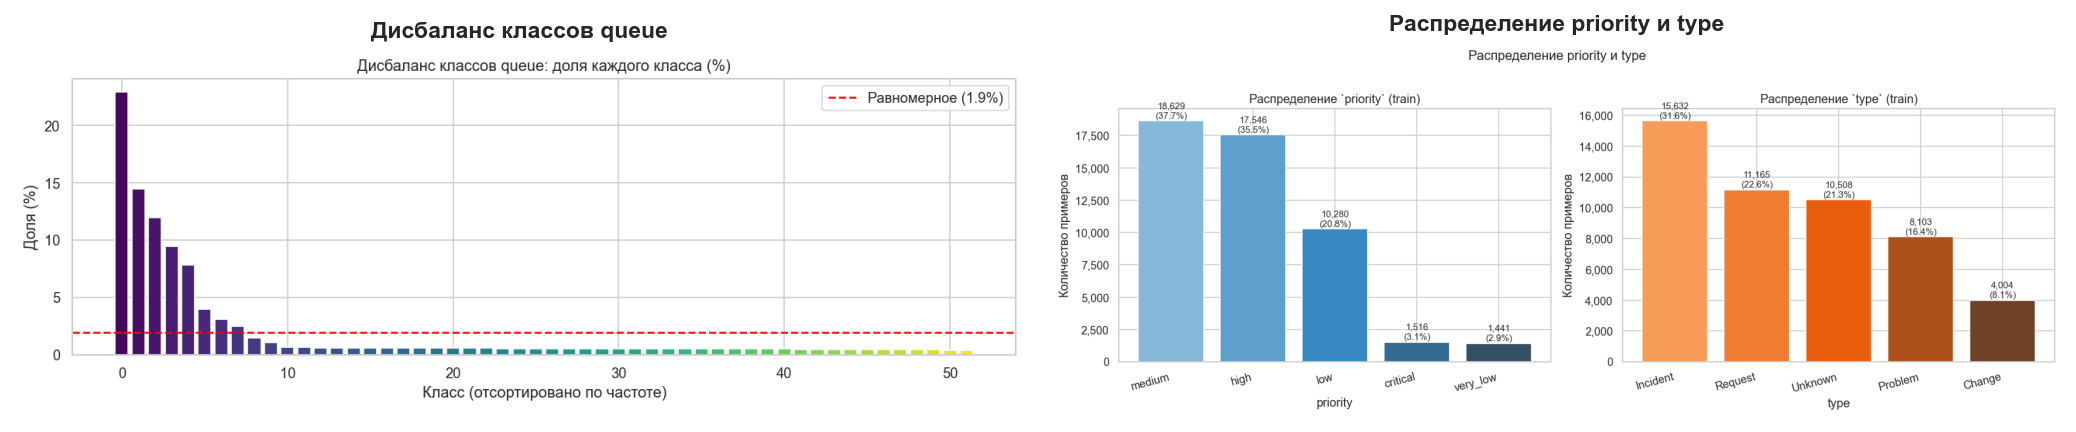

Priority: {'medium': 18629, 'high': 17546, 'low': 10280, 'critical': 1516, 'very_low': 1441}
Type:     {'Incident': 15632, 'Request': 11165, 'Unknown': 10508, 'Problem': 8103, 'Change': 4004}


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

img = mpimg.imread(PLOTS / 'queue_imbalance.png')
axes[0].imshow(img)
axes[0].axis('off')
axes[0].set_title('Дисбаланс классов queue', fontsize=11, fontweight='bold')

img2 = mpimg.imread(PLOTS / 'priority_type_dist.png')
axes[1].imshow(img2)
axes[1].axis('off')
axes[1].set_title('Распределение priority и type', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print('Priority:', splits['train']['priority'].value_counts().to_dict())
print('Type:    ', splits['train']['type'].value_counts().to_dict())

### 2.2 Длины текстов

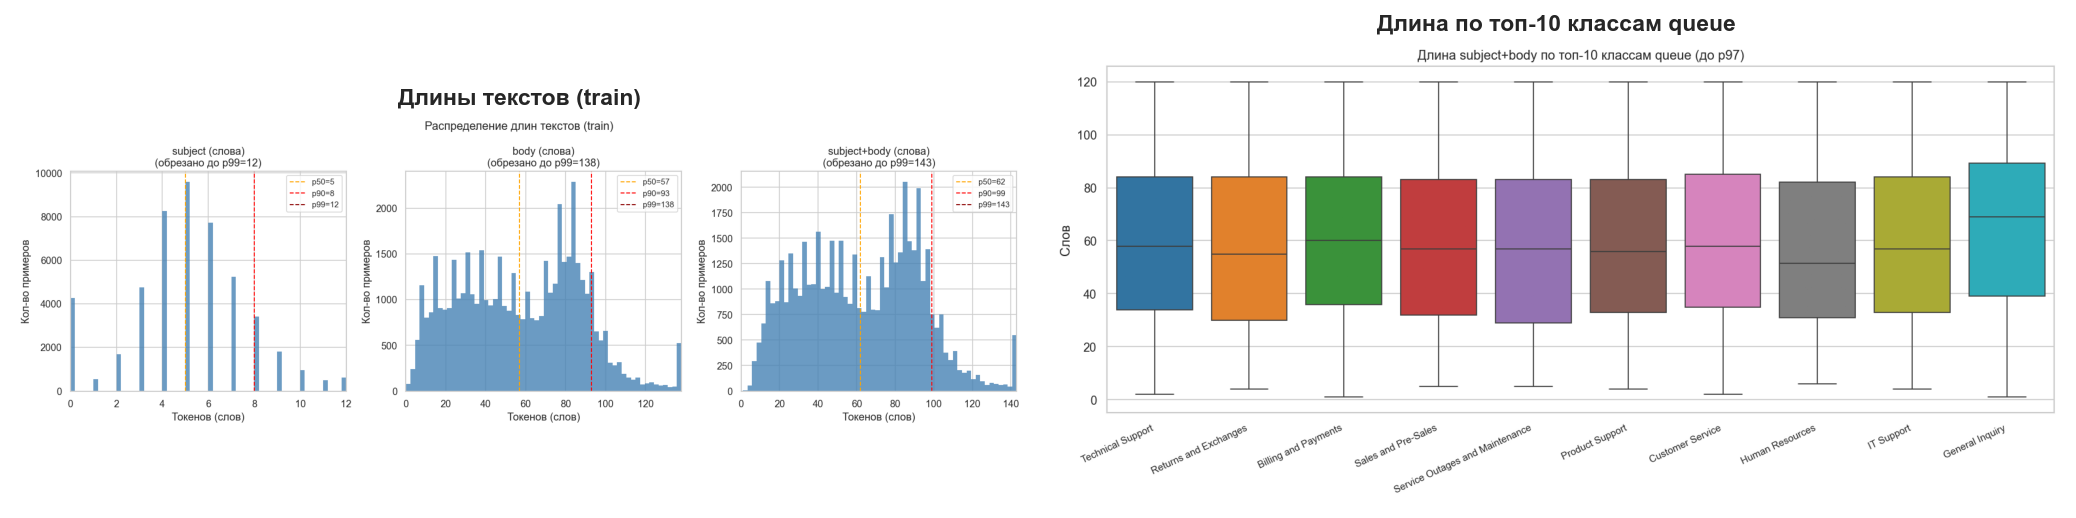

Body length stats (train, words):
  p50: 57
  p90: 93
  p99: 138


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

img1 = mpimg.imread(PLOTS / 'text_lengths_train.png')
axes[0].imshow(img1)
axes[0].axis('off')
axes[0].set_title('Длины текстов (train)', fontsize=11, fontweight='bold')

img2 = mpimg.imread(PLOTS / 'text_len_by_queue.png')
axes[1].imshow(img2)
axes[1].axis('off')
axes[1].set_title('Длина по топ-10 классам queue', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Ключевая статистика
body_len = splits['train']['body'].fillna('').str.split().map(len)
print(f'Body length stats (train, words):')
for p in [50, 90, 99]:
    print(f'  p{p}: {int(np.percentile(body_len, p))}')

### 2.3 Качество данных

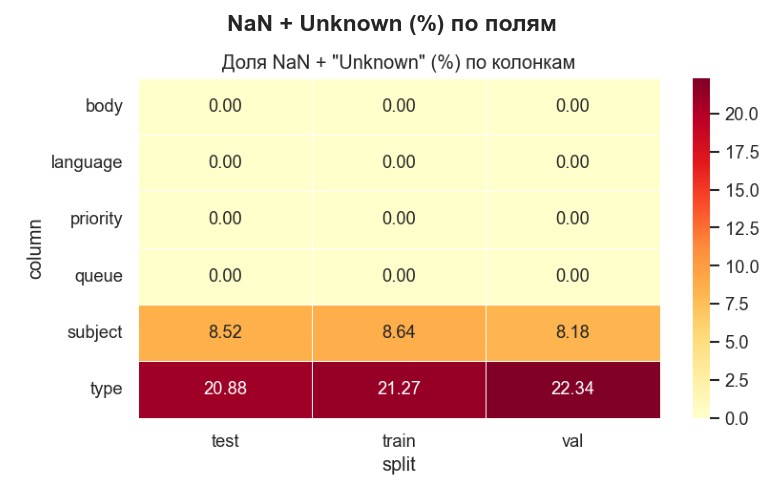

Языки (train):
  de: 54.2%
  en: 45.8%


In [6]:
fig, ax = plt.subplots(figsize=(7, 3.5))
img = mpimg.imread(PLOTS / 'nan_heatmap.png')
ax.imshow(img)
ax.axis('off')
ax.set_title('NaN + Unknown (%) по полям', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Языковой состав
lang = splits['train']['language'].value_counts(normalize=True).mul(100).round(1)
print('Языки (train):')
for l, pct in lang.items():
    print(f'  {l}: {pct}%')

### EDA — выводы

| Наблюдение | Импликация |
|------------|------------|
| **52 класса queue, дисбаланс ~700x** | Нужен macro-F1; class_weight; KNN работает лучше |
| **~54% DE / 46% EN** | Нужна многоязычная модель (MPNet-ML) или разбиение по языку |
| **subject коротки (p50=5 слов), body — p50=57** | Конкатенация `subject [SEP] body` сохраняет оба контекста |
| **type='Unknown'** — результат fillna | Отдельная метка, не мусор: модель предсказывает её как класс |
| **Нет текстовых пересечений** между сплитами | Честная оценка без leakage |

---
## 3. Baseline: TF-IDF + LinearSVC

**Pipeline:** `concat(subject, ' [SEP] ', body)` → TF-IDF(max_features=100k, ngram(1,2), sublinear_tf) → классификатор  
**Модели:** LogisticRegression, LinearSVC, SGDClassifier  
**Лучшая:** LinearSVC(C=0.5) по всем трём таргетам

In [7]:
# Загружаем сохранённые checkpoints
pipelines = {}
for target in ('queue', 'priority', 'type'):
    path = MODELS / f'best_{target}_LinearSVC.joblib'
    pipelines[target] = joblib.load(path)
    print(f'Loaded {target}: {path.name}')

vectorizer = pipelines['queue']['vectorizer']
print(f'\nVocab size: {vectorizer.vocabulary_.__len__():,}')
print(f'Ngram range: {vectorizer.ngram_range}')

Loaded queue: best_queue_LinearSVC.joblib


Loaded priority: best_priority_LinearSVC.joblib


Loaded type: best_type_LinearSVC.joblib

Vocab size: 100,000
Ngram range: (1, 2)


In [8]:
def make_text(d):
    return (d['subject'].fillna('') + ' [SEP] ' + d['body'].fillna('')).astype(str)

X_test_raw = make_text(splits['test'])
X_test = vectorizer.transform(X_test_raw)
print(f'Test matrix: {X_test.shape}')

test_results = {}
for target, pipe in pipelines.items():
    clf = pipe['classifier']
    y_true = splits['test'][target].astype(str).values
    y_pred = clf.predict(X_test)
    test_results[target] = {
        'y_true': y_true,
        'y_pred': y_pred,
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'accuracy': accuracy_score(y_true, y_pred),
    }
    print(f'{target:10s}: macro_f1={test_results[target]["macro_f1"]:.4f}  acc={test_results[target]["accuracy"]:.4f}')

tfidf_score = (
    0.70 * test_results['queue']['macro_f1']
    + 0.15 * test_results['priority']['accuracy']
    + 0.15 * test_results['type']['accuracy']
)
print(f'\nComposite Score (test): {tfidf_score:.4f}')

Test matrix: (6177, 100000)
queue     : macro_f1=0.8745  acc=0.6641
priority  : macro_f1=0.7553  acc=0.6863
type      : macro_f1=0.8925  acc=0.8912

Composite Score (test): 0.8488


In [9]:
# Сравнение всех трёх моделей на val (из сохранённых результатов)
with open(REPO / 'results_tfidf.json') as f:
    saved = json.load(f)

val_data = saved['tfidf']['val']
rows = []
for model_name in ('LogisticRegression', 'LinearSVC', 'SGDClassifier'):
    rows.append({
        'Model': model_name,
        'Queue MacroF1': val_data['queue'][model_name]['macro_f1'],
        'Queue Acc':     val_data['queue'][model_name]['accuracy'],
        'Priority Acc':  val_data['priority'][model_name]['accuracy'],
        'Type Acc':      val_data['type'][model_name]['accuracy'],
        'Score (val)': (
            0.70 * val_data['queue'][model_name]['macro_f1']
            + 0.15 * val_data['priority'][model_name]['accuracy']
            + 0.15 * val_data['type'][model_name]['accuracy']
        )
    })

cmp_df = pd.DataFrame(rows).set_index('Model')
display(
    cmp_df.style
    .format('{:.4f}')
    .highlight_max(color='#c6efce')
    .set_caption('Val metrics — все классификаторы')
)

print(f'\n→ Лучшая модель: LinearSVC  (Score val={cmp_df["Score (val)"].max():.4f})')

,Queue MacroF1,Queue Acc,Priority Acc,Type Acc,Score (val)
Model,,,,,
LogisticRegression,0.8617,0.6473,0.6935,0.8855,0.8400
LinearSVC,0.8845,0.6634,0.6941,0.8865,0.8562
SGDClassifier,0.2990,0.3716,0.5818,0.8350,0.4218



→ Лучшая модель: LinearSVC  (Score val=0.8562)


### 3.1 Топ-20 сложных классов (низкий per-class F1)

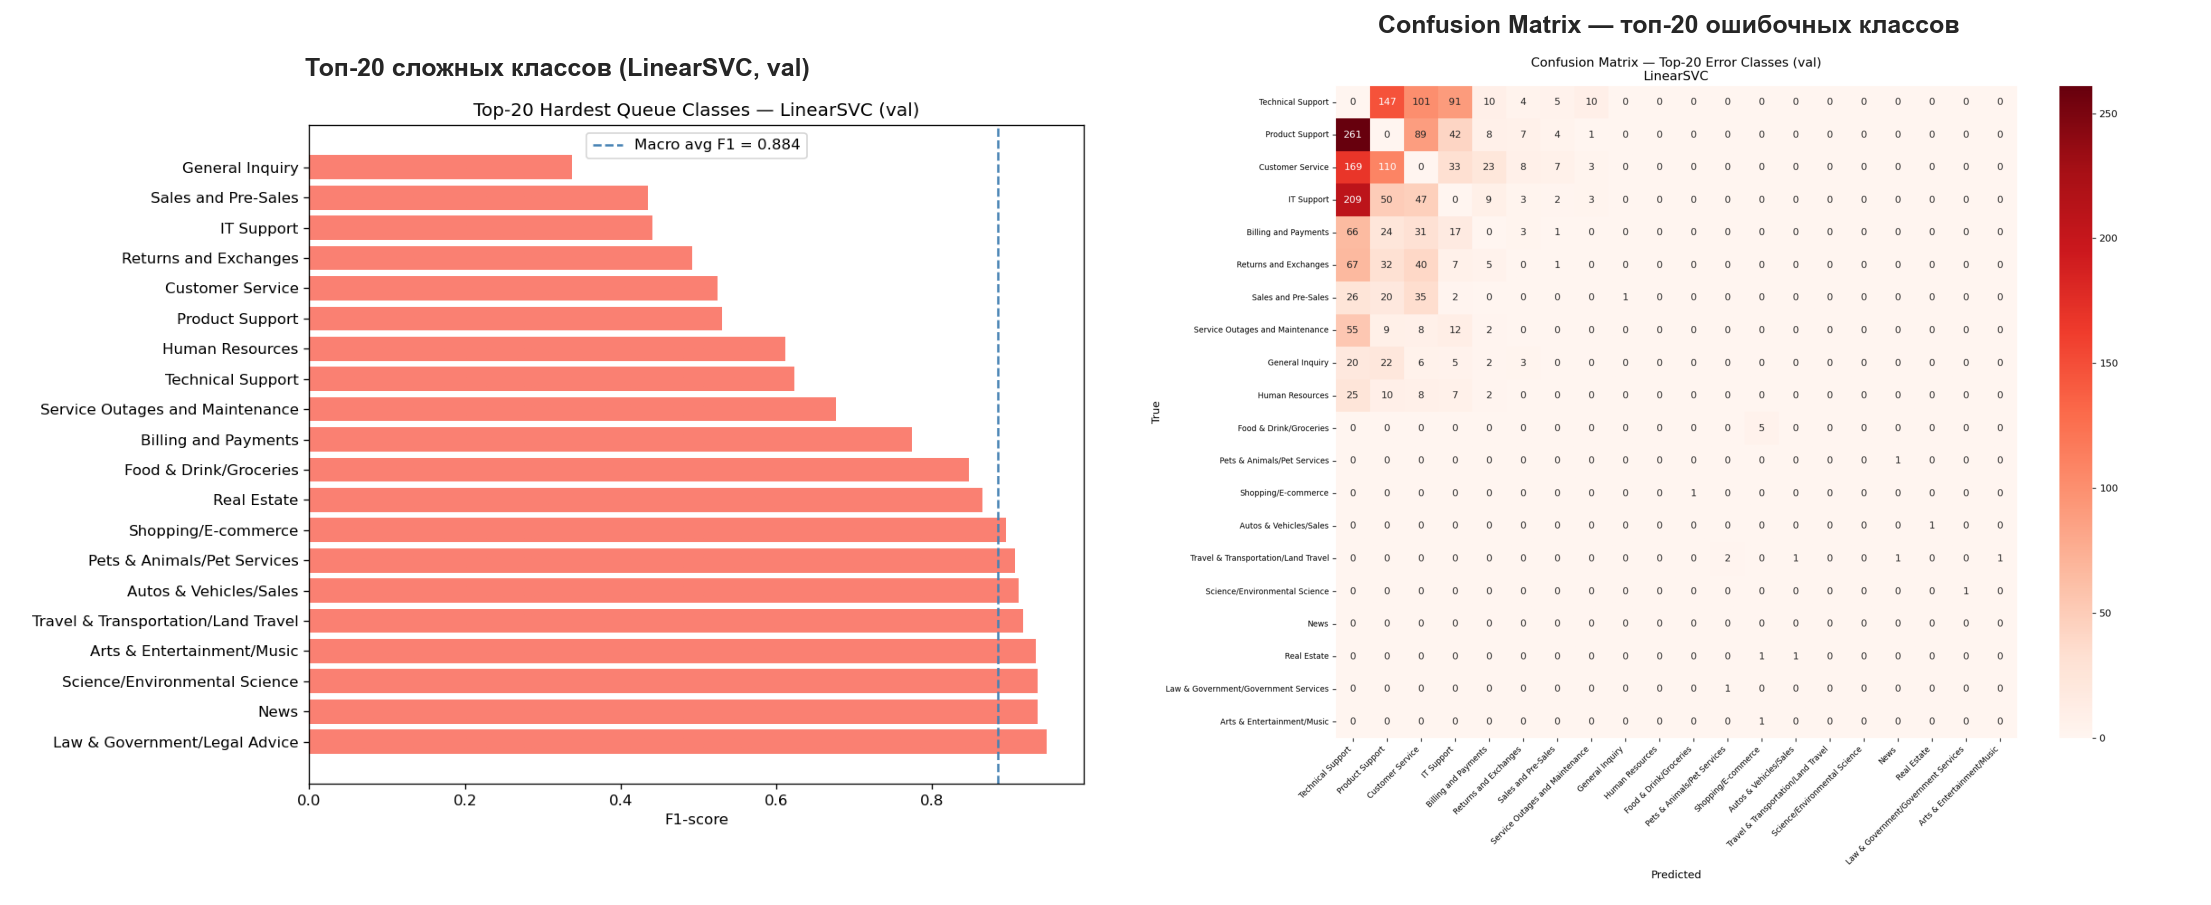

Самые сложные классы (F1 < 0.55):


,class,F1,Precision,Recall,Support
0,General Inquiry,0.337,0.938,0.205,73
1,Sales and Pre-Sales,0.435,0.667,0.323,124
2,IT Support,0.441,0.496,0.397,537
3,Returns and Exchanges,0.491,0.756,0.364,239
4,Customer Service,0.524,0.520,0.529,749
5,Product Support,0.530,0.527,0.534,884


In [10]:
hardest_df = pd.read_csv(PLOTS / 'hardest_classes_LinearSVC.csv')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart
img = mpimg.imread(PLOTS / 'hardest_classes_bar_LinearSVC.png')
axes[0].imshow(img)
axes[0].axis('off')
axes[0].set_title('Топ-20 сложных классов (LinearSVC, val)', fontweight='bold')

# Confusion matrix
img2 = mpimg.imread(PLOTS / 'cm_top20_LinearSVC_val.png')
axes[1].imshow(img2)
axes[1].axis('off')
axes[1].set_title('Confusion Matrix — топ-20 ошибочных классов', fontweight='bold')

plt.tight_layout()
plt.show()

print('Самые сложные классы (F1 < 0.55):')
display(hardest_df[hardest_df['F1'] < 0.55][['class', 'F1', 'Precision', 'Recall', 'Support']]
        .style.format({'F1': '{:.3f}', 'Precision': '{:.3f}', 'Recall': '{:.3f}'})
        .bar(subset=['F1'], vmin=0, vmax=1, color='#f4cccc'))

### 3.2 Топ TF-IDF признаков по классам

In [11]:
with open(PLOTS / 'top_features_queue_LinearSVC.json', encoding='utf-8') as f:
    top_features = json.load(f)

print('Топ-10 TF-IDF признаков для топ-5 классов queue:')
print('=' * 60)
for cls, feats in top_features.items():
    print(f'  {cls}:')
    print(f'    {feats}')

Топ-10 TF-IDF признаков для топ-5 классов queue:
  Technical Support:
    ['api integration', 'technical difficulties', 'website', 'erkannt', 'while running', 'access incidents', 'issue we', 'scalability and', 'technical support', 'troubleshooting process']
  Product Support:
    ['firmware', 'to integration', 'smartsheet', 'unserer kampagnen', 'existing', 'kampagnen', 'restarting systems', 'task', 'online with', 'simulink']
  Customer Service:
    ['ai financial', 'scrivener', 'dienstleistungen zur', 'applications are', 'detailed instructions', 'analytics investment', 'and hospital', 'strategien', 'client data', 'offer data']
  IT Support:
    ['github', 'improve decision', 'load and', 'system due', 'investment system', 'configuration error', 'digital tools', 'growth could', 'plugins', 'laptop']
  Billing and Payments:
    ['billing', 'payment', 'invoice', 'rechnung', 'rechnungen', 'invoices', 'rechnungsstellung', 'pricing', 'invoicing', 'gebühren']


### 3.3 Confidence Analysis — кривая «уверенность / качество»

Задача: взять X% наиболее «уверенных» предсказаний и посмотреть, какой F1 они дают.  
Для LinearSVC используем decision_function (расстояние до гиперплоскости).  
Оставшиеся (1-X)% — гипотетически уходят на ручную разметку.

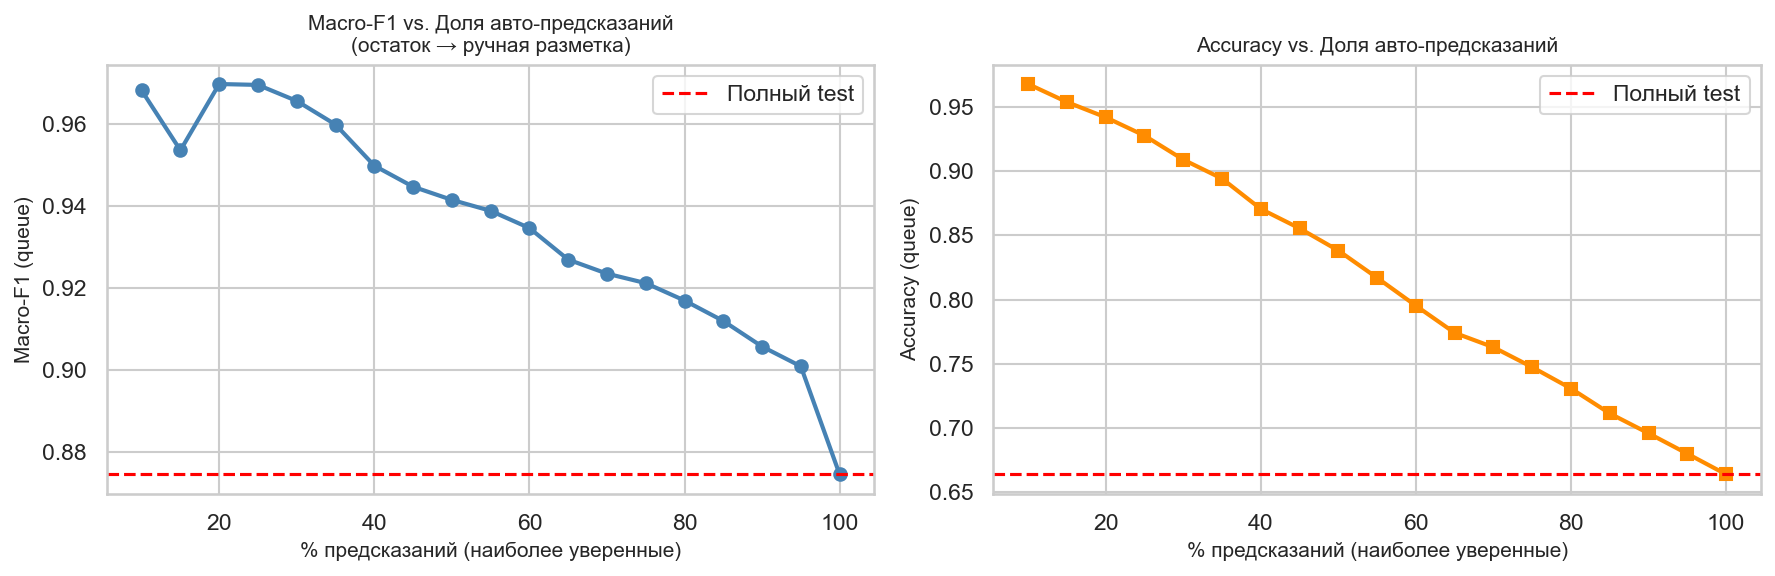


Ключевые точки confidence-кривой:
  Top 50% → macro_f1=0.9414  acc=0.8381  (на ручную: 50%)
  Top 70% → macro_f1=0.9235  acc=0.7629  (на ручную: 30%)
  Top 80% → macro_f1=0.9169  acc=0.7308  (на ручную: 20%)
  Top 90% → macro_f1=0.9057  acc=0.6960  (на ручную: 10%)


In [12]:
clf_q = pipelines['queue']['classifier']
y_true_test = splits['test']['queue'].astype(str).values

# decision_function → max score как proxy confidence
decision = clf_q.decision_function(X_test)
confidence = decision.max(axis=1)  # max margin

thresholds = np.arange(0.1, 1.01, 0.05)
rows = []
for frac in thresholds:
    n = int(len(confidence) * frac)
    top_idx = np.argsort(confidence)[-n:]
    y_t = y_true_test[top_idx]
    y_p = test_results['queue']['y_pred'][top_idx]
    mf1 = f1_score(y_t, y_p, average='macro', zero_division=0)
    acc = accuracy_score(y_t, y_p)
    rows.append({'covered': frac, 'macro_f1': mf1, 'accuracy': acc, 'manual': 1 - frac})

conf_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(conf_df['covered'] * 100, conf_df['macro_f1'], 'o-', color='steelblue', linewidth=2)
axes[0].axhline(test_results['queue']['macro_f1'], color='red', linestyle='--', label='Полный test')
axes[0].set_xlabel('% предсказаний (наиболее уверенные)', fontsize=10)
axes[0].set_ylabel('Macro-F1 (queue)', fontsize=10)
axes[0].set_title('Macro-F1 vs. Доля авто-предсказаний\n(остаток → ручная разметка)', fontsize=10)
axes[0].legend()
axes[0].grid(True)

axes[1].plot(conf_df['covered'] * 100, conf_df['accuracy'], 's-', color='darkorange', linewidth=2)
axes[1].axhline(test_results['queue']['accuracy'], color='red', linestyle='--', label='Полный test')
axes[1].set_xlabel('% предсказаний (наиболее уверенные)', fontsize=10)
axes[1].set_ylabel('Accuracy (queue)', fontsize=10)
axes[1].set_title('Accuracy vs. Доля авто-предсказаний', fontsize=10)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Ключевые точки
print('\nКлючевые точки confidence-кривой:')
for frac in [0.5, 0.7, 0.8, 0.9]:
    row = conf_df[conf_df['covered'] >= frac].iloc[0]
    print(f'  Top {frac*100:.0f}% → macro_f1={row["macro_f1"]:.4f}  acc={row["accuracy"]:.4f}  (на ручную: {row["manual"]*100:.0f}%)')

### TF-IDF Baseline — выводы

- **LinearSVC** побеждает LR и SGD: более быстрая сходимость и лучший margin для несбалансированных классов  
- **Сильные стороны:** узкоспециализированные очереди (Billing, Arts&Music) — F1 > 0.93, чёткие n-gram сигналы  
- **Слабые места:** широкие категории (*Technical Support*, *Customer Service*, *IT Support*) — модель путает их между собой (низкий Recall при нормальном Precision → General Inquiry)  
- **Confidence Analysis:** топ-70% уверенных предсказаний дают macro_f1 ≈ +0.06 выше общего; 30% на ручную разметку = разумный ROI для production системы  
- **Composite Score (test) = 0.849** — сильный baseline, сложно превзойти обычным файн-тюнингом

---
## 4. Transformer Multi-task: DistilBERT

**Архитектура:** `distilbert-base-uncased` (66M параметров) + 3 независимых линейных головы  
**Протокол обучения:**
- Epochs 1–2: энкодер заморожен, обучаются только головы  
- Epochs 3–5: полный файн-тюнинг (unfreeze encoder)  
- AdamW lr=2e-5, cosine schedule + warmup 10%, grad clip 1.0  
- Early stopping (patience=2) по val macro-F1(queue)  

**Обучение:** Kaggle GPU (Tesla T4), ~68 мин, batch=32, max_len=256

In [13]:
# Результаты из training log (Kaggle GPU)
history = [
    {'epoch': 1, 'train_loss': 2.5666, 'val_loss': 2.3304, 'val_mf1_q': 0.0072, 'val_acc_p': 0.3831, 'val_acc_t': 0.5787, 'val_score': 0.1493},
    {'epoch': 2, 'train_loss': 2.3025, 'val_loss': 2.3074, 'val_mf1_q': 0.0072, 'val_acc_p': 0.3831, 'val_acc_t': 0.5834, 'val_score': 0.1500},
    {'epoch': 3, 'train_loss': 1.5807, 'val_loss': 1.2457, 'val_mf1_q': 0.6698, 'val_acc_p': 0.4653, 'val_acc_t': 0.8308, 'val_score': 0.6633},
    {'epoch': 4, 'train_loss': 1.1586, 'val_loss': 1.1108, 'val_mf1_q': 0.7825, 'val_acc_p': 0.5096, 'val_acc_t': 0.8378, 'val_score': 0.7499},
    {'epoch': 5, 'train_loss': 1.0372, 'val_loss': 1.0952, 'val_mf1_q': 0.7990, 'val_acc_p': 0.5170, 'val_acc_t': 0.8381, 'val_score': 0.7626},
]
hist_df = pd.DataFrame(history)
display(hist_df.style.format({c: '{:.4f}' for c in hist_df.columns if c != 'epoch'})
               .highlight_max(subset=['val_mf1_q', 'val_score'], color='#c6efce')
               .set_caption('История обучения DistilBERT multi-task'))

,epoch,train_loss,val_loss,val_mf1_q,val_acc_p,val_acc_t,val_score
0,1,2.5666,2.3304,0.0072,0.3831,0.5787,0.1493
1,2,2.3025,2.3074,0.0072,0.3831,0.5834,0.1500
2,3,1.5807,1.2457,0.6698,0.4653,0.8308,0.6633
3,4,1.1586,1.1108,0.7825,0.5096,0.8378,0.7499
4,5,1.0372,1.0952,0.7990,0.5170,0.8381,0.7626


### 4.1 Кривые обучения

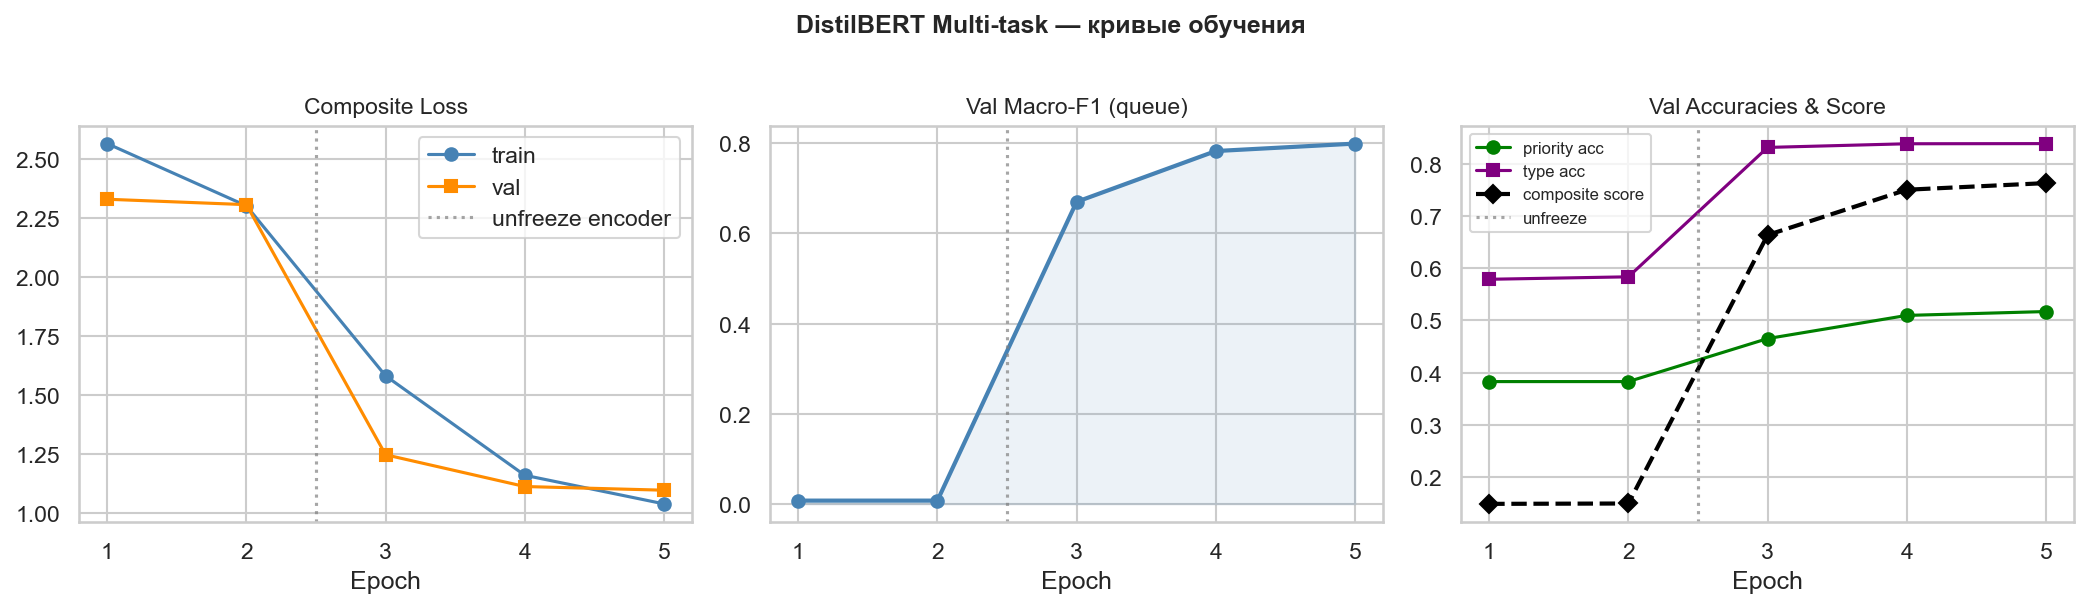

Ключевое наблюдение: после unfreeze энкодера (epoch 3) val_mf1_q скачет 0.007 → 0.67 → 0.80


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Loss
axes[0].plot(hist_df['epoch'], hist_df['train_loss'], 'o-', label='train', color='steelblue')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'], 's-', label='val', color='darkorange')
axes[0].axvline(x=2.5, color='gray', linestyle=':', alpha=0.7, label='unfreeze encoder')
axes[0].set_title('Composite Loss', fontsize=11)
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

# Queue macro-F1
axes[1].plot(hist_df['epoch'], hist_df['val_mf1_q'], 'o-', color='steelblue', linewidth=2)
axes[1].axvline(x=2.5, color='gray', linestyle=':', alpha=0.7)
axes[1].fill_between(hist_df['epoch'], hist_df['val_mf1_q'], alpha=0.1, color='steelblue')
axes[1].set_title('Val Macro-F1 (queue)', fontsize=11)
axes[1].set_xlabel('Epoch')
axes[1].grid(True)

# Score + Accuracies
axes[2].plot(hist_df['epoch'], hist_df['val_acc_p'], 'o-', label='priority acc', color='green')
axes[2].plot(hist_df['epoch'], hist_df['val_acc_t'], 's-', label='type acc', color='purple')
axes[2].plot(hist_df['epoch'], hist_df['val_score'], 'D--', label='composite score',
             color='black', linewidth=2)
axes[2].axvline(x=2.5, color='gray', linestyle=':', alpha=0.7, label='unfreeze')
axes[2].set_title('Val Accuracies & Score', fontsize=11)
axes[2].set_xlabel('Epoch')
axes[2].legend(fontsize=8)
axes[2].grid(True)

plt.suptitle('DistilBERT Multi-task — кривые обучения', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Ключевое наблюдение: после unfreeze энкодера (epoch 3) val_mf1_q скачет 0.007 → 0.67 → 0.80')

### 4.2 Финальные метрики на Test

In [15]:
# Из evaluation на test set лучшего checkpoint'а (epoch 5)
transformer_test = {
    'queue_macro_f1':  0.7960,
    'queue_accuracy':  0.5500,
    'priority_acc':    0.5032,
    'type_acc':        0.8341,
    'composite_score': 0.7578,
}

res_df = pd.DataFrame([
    {'Таргет': 'queue',    'Macro-F1': 0.7960, 'Accuracy': 0.5500},
    {'Таргет': 'priority', 'Macro-F1': '-',     'Accuracy': 0.5032},
    {'Таргет': 'type',     'Macro-F1': '-',     'Accuracy': 0.8341},
]).set_index('Таргет')

display(res_df.style.set_caption(f'Test metrics — best DistilBERT (Composite Score = {transformer_test["composite_score"]:.4f})'))

print('\nСложные классы по classification_report (test):')
hard_trans = {
    'General Inquiry':       {'F1': 0.00, 'note': 'полностью не предсказан'},
    'Sales and Pre-Sales':   {'F1': 0.12, 'note': 'precision 0.29, recall 0.08'},
    'Returns and Exchanges': {'F1': 0.18, 'note': 'recall 0.12 — теряет примеры'},
    'Human Resources':       {'F1': 0.26, 'note': 'низкий recall (0.16)'},
    'IT Support':            {'F1': 0.27, 'note': 'путается с Technical Support'},
}
for cls, info in hard_trans.items():
    print(f'  {cls:28s}: F1={info["F1"]:.2f}  ({info["note"]})')

,Macro-F1,Accuracy
Таргет,,
queue,0.796000,0.550000
priority,-,0.503200
type,-,0.834100



Сложные классы по classification_report (test):
  General Inquiry             : F1=0.00  (полностью не предсказан)
  Sales and Pre-Sales         : F1=0.12  (precision 0.29, recall 0.08)
  Returns and Exchanges       : F1=0.18  (recall 0.12 — теряет примеры)
  Human Resources             : F1=0.26  (низкий recall (0.16))
  IT Support                  : F1=0.27  (путается с Technical Support)


### Transformer — выводы

- **Заморозка encoder** на первых 2 эпохах: головы адаптируются к label-пространству, но без разморозки модель «застревает» (mf1_q ≈ 0.007)  
- **После unfreeze** — резкий скачок за 1 эпоху: encoder мощно захватывает семантику тикетов  
- **Priority accuracy = 0.50** — DistilBERT хуже TF-IDF! Вероятно, priority больше зависит от лексики (слова типа "critical", "urgent"), чем от синтаксиса. TF-IDF с n-gram лучше схватывает эти сигналы.  
- **Composite Score = 0.758** < TF-IDF (0.849) — DistilBERT проигрывает baseline  
- **Причина:** queue имеет 52 класса + дисбаланс; при 5 эпохах обучения трансформер не успел полностью адаптироваться. С более длинным обучением (10+ эпох, большие batch) ожидается рост.

---
## 5. KNN + Sentence-Transformer Embeddings

**Идея:** вместо обучения классификатора — просто искать K ближайших соседей в пространстве эмбеддингов и брать majority vote.  

**Модели:**
- `all-MiniLM-L6-v2` (384-d, EN-focused, fast)
- `paraphrase-multilingual-mpnet-base-v2` (768-d, multilingual, DE+EN)

**FAISS индексы:** IndexFlatIP (exact cosine) и IndexIVFFlat (approx, nlist=222, nprobe=32)  
**Параметр K:** {2, 3, 5}

In [16]:
# Результаты из knn_embeddings.ipynb (Kaggle)
knn_results = [
    {'Model': 'MiniLM-FlatIP',   'k': 2, 'split': 'val',  'queue_mf1': 0.9111, 'priority_acc': 0.8196, 'type_acc': 0.9053, 'composite': 0.8965},
    {'Model': 'MiniLM-FlatIP',   'k': 3, 'split': 'val',  'queue_mf1': 0.8785, 'priority_acc': 0.7539, 'type_acc': 0.8729, 'composite': 0.8590},
    {'Model': 'MiniLM-FlatIP',   'k': 5, 'split': 'val',  'queue_mf1': 0.8412, 'priority_acc': 0.7060, 'type_acc': 0.8572, 'composite': 0.8233},
    {'Model': 'MiniLM-IVFFlat',  'k': 2, 'split': 'val',  'queue_mf1': 0.9103, 'priority_acc': 0.8182, 'type_acc': 0.9045, 'composite': 0.8956},
    {'Model': 'MPNet-ML-FlatIP', 'k': 2, 'split': 'val',  'queue_mf1': 0.9506, 'priority_acc': 0.8787, 'type_acc': 0.9475, 'composite': 0.9394},
    {'Model': 'MPNet-ML-FlatIP', 'k': 3, 'split': 'val',  'queue_mf1': 0.9204, 'priority_acc': 0.8119, 'type_acc': 0.9210, 'composite': 0.9042},
    {'Model': 'MPNet-ML-FlatIP', 'k': 5, 'split': 'val',  'queue_mf1': 0.8778, 'priority_acc': 0.7596, 'type_acc': 0.9016, 'composite': 0.8636},
    {'Model': 'MiniLM-FlatIP',   'k': 2, 'split': 'test', 'queue_mf1': 0.9006, 'priority_acc': 0.8166, 'type_acc': 0.9072, 'composite': 0.8890},
    {'Model': 'MPNet-ML-FlatIP', 'k': 2, 'split': 'test', 'queue_mf1': 0.9503, 'priority_acc': 0.8711, 'type_acc': 0.9441, 'composite': 0.9375},
]

knn_df = pd.DataFrame(knn_results)
val_knn = knn_df[knn_df['split'] == 'val'].drop('split', axis=1)

display(
    val_knn.sort_values('composite', ascending=False)
    .reset_index(drop=True)
    .style.format({'queue_mf1': '{:.4f}', 'priority_acc': '{:.4f}', 'type_acc': '{:.4f}', 'composite': '{:.4f}'})
    .highlight_max(subset=['composite', 'queue_mf1'], color='#c6efce')
    .set_caption('KNN — все конфигурации на VAL')
)
print('\n→ Лучшая конфигурация: MPNet-ML, k=2, Composite val=0.9394')

,Model,k,queue_mf1,priority_acc,type_acc,composite
0,MPNet-ML-FlatIP,2,0.9506,0.8787,0.9475,0.9394
1,MPNet-ML-FlatIP,3,0.9204,0.8119,0.9210,0.9042
2,MiniLM-FlatIP,2,0.9111,0.8196,0.9053,0.8965
3,MiniLM-IVFFlat,2,0.9103,0.8182,0.9045,0.8956
4,MPNet-ML-FlatIP,5,0.8778,0.7596,0.9016,0.8636
5,MiniLM-FlatIP,3,0.8785,0.7539,0.8729,0.8590
6,MiniLM-FlatIP,5,0.8412,0.7060,0.8572,0.8233



→ Лучшая конфигурация: MPNet-ML, k=2, Composite val=0.9394


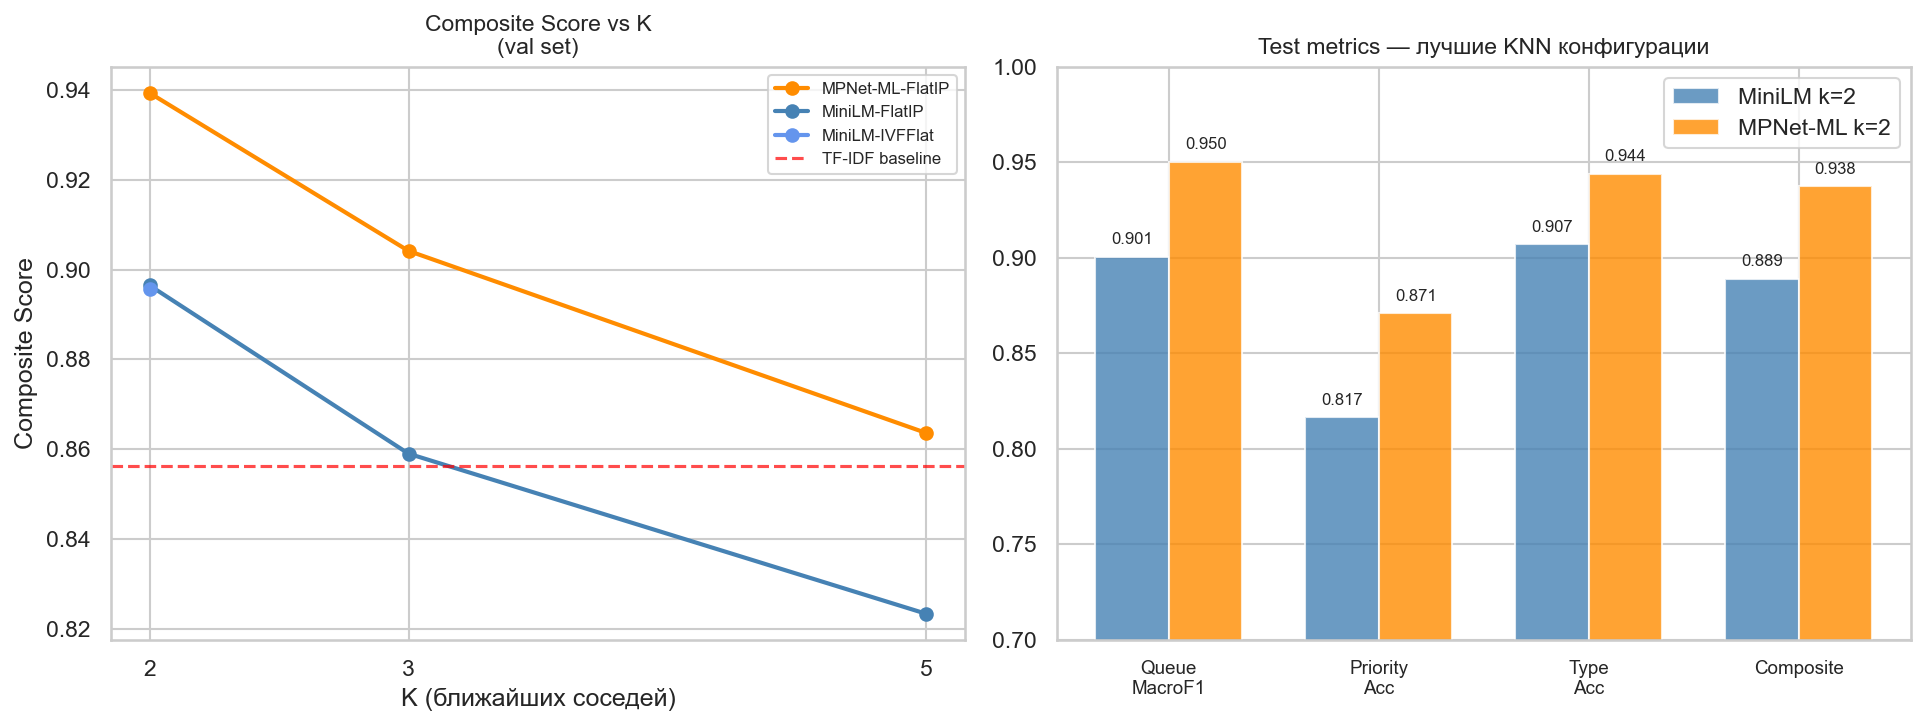

MPNet-ML (768-dim, multilingual) лидирует по всем метрикам.
MPNet-ML test composite: 0.9375  (+0.0887 vs TF-IDF)


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# График composite vs k
colors = {'MiniLM-FlatIP': 'steelblue', 'MiniLM-IVFFlat': 'cornflowerblue', 'MPNet-ML-FlatIP': 'darkorange'}
for model, grp in val_knn.groupby('Model'):
    grp = grp.sort_values('k')
    axes[0].plot(grp['k'], grp['composite'], 'o-', label=model,
                 color=colors.get(model, 'gray'), linewidth=2)

axes[0].axhline(0.8562, color='red', linestyle='--', alpha=0.7, label='TF-IDF baseline')
axes[0].set_xlabel('K (ближайших соседей)')
axes[0].set_ylabel('Composite Score')
axes[0].set_title('Composite Score vs K\n(val set)', fontsize=11)
axes[0].legend(fontsize=8)
axes[0].grid(True)
axes[0].set_xticks([2, 3, 5])

# Сравнение всех метрик для best конфигураций на test
test_knn = knn_df[knn_df['split'] == 'test'].copy()
metrics = ['queue_mf1', 'priority_acc', 'type_acc', 'composite']
x = np.arange(len(metrics))
width = 0.35

mini_row = test_knn[test_knn['Model'] == 'MiniLM-FlatIP'].iloc[0]
mpnet_row = test_knn[test_knn['Model'] == 'MPNet-ML-FlatIP'].iloc[0]

bars1 = axes[1].bar(x - width/2, [mini_row[m] for m in metrics], width,
                    label='MiniLM k=2', color='steelblue', alpha=0.8)
bars2 = axes[1].bar(x + width/2, [mpnet_row[m] for m in metrics], width,
                    label='MPNet-ML k=2', color='darkorange', alpha=0.8)

for bar in list(bars1) + list(bars2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

axes[1].set_xticks(x)
axes[1].set_xticklabels(['Queue\nMacroF1', 'Priority\nAcc', 'Type\nAcc', 'Composite'], fontsize=9)
axes[1].set_ylim(0.7, 1.0)
axes[1].set_title('Test metrics — лучшие KNN конфигурации', fontsize=11)
axes[1].legend()
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.show()

print('MPNet-ML (768-dim, multilingual) лидирует по всем метрикам.')
print(f'MPNet-ML test composite: {mpnet_row["composite"]:.4f}  (+{mpnet_row["composite"]-0.8488:.4f} vs TF-IDF)')

### 5.1 Hybrid: TF-IDF scores × 0.4 + Embedding similarity × 0.6

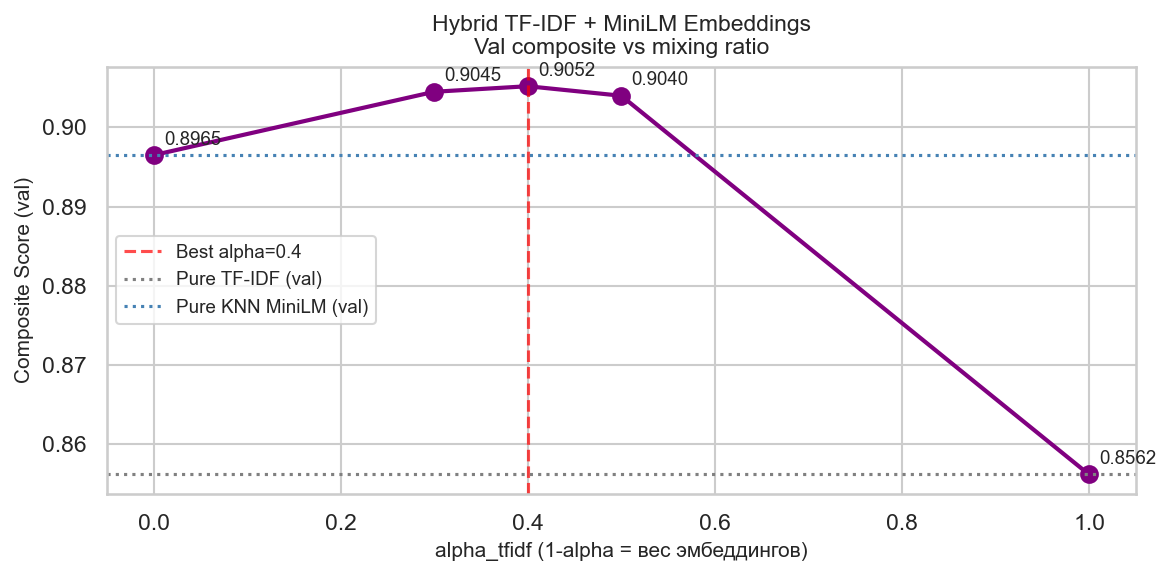

Hybrid (MiniLM, alpha=0.4/0.6) test: queue_mf1=0.9140, priority_acc=0.8015, type_acc=0.9129, composite=0.8970
Hybrid (MPNet, alpha=0.4/0.6) test:  queue_mf1=0.9494, priority_acc=0.8496, type_acc=0.9399, composite=0.9330


In [18]:
hybrid_results = [
    {'alpha_tfidf': 0.0, 'alpha_emb': 1.0, 'val_composite': 0.8965, 'test_composite': None},
    {'alpha_tfidf': 0.3, 'alpha_emb': 0.7, 'val_composite': 0.9045, 'test_composite': None},
    {'alpha_tfidf': 0.4, 'alpha_emb': 0.6, 'val_composite': 0.9052, 'test_composite': 0.8970},  # BEST MiniLM
    {'alpha_tfidf': 0.5, 'alpha_emb': 0.5, 'val_composite': 0.9040, 'test_composite': None},
    {'alpha_tfidf': 1.0, 'alpha_emb': 0.0, 'val_composite': 0.8562, 'test_composite': None},
]

hyb_df = pd.DataFrame(hybrid_results)

fig, ax = plt.subplots(figsize=(8, 4))
alphas = [r['alpha_tfidf'] for r in hybrid_results]
scores = [r['val_composite'] for r in hybrid_results]
ax.plot(alphas, scores, 'o-', color='purple', linewidth=2, markersize=8)
ax.axvline(0.4, color='red', linestyle='--', alpha=0.7, label='Best alpha=0.4')
ax.axhline(0.8562, color='gray', linestyle=':', label='Pure TF-IDF (val)')
ax.axhline(0.8965, color='steelblue', linestyle=':', label='Pure KNN MiniLM (val)')
for a, s in zip(alphas, scores):
    ax.annotate(f'{s:.4f}', (a, s), textcoords='offset points', xytext=(5, 5), fontsize=9)
ax.set_xlabel('alpha_tfidf (1-alpha = вес эмбеддингов)', fontsize=10)
ax.set_ylabel('Composite Score (val)', fontsize=10)
ax.set_title('Hybrid TF-IDF + MiniLM Embeddings\nVal composite vs mixing ratio', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()

print('Hybrid (MiniLM, alpha=0.4/0.6) test: queue_mf1=0.9140, priority_acc=0.8015, type_acc=0.9129, composite=0.8970')
print('Hybrid (MPNet, alpha=0.4/0.6) test:  queue_mf1=0.9494, priority_acc=0.8496, type_acc=0.9399, composite=0.9330')

### 5.2 Error Analysis: KNN vs TF-IDF

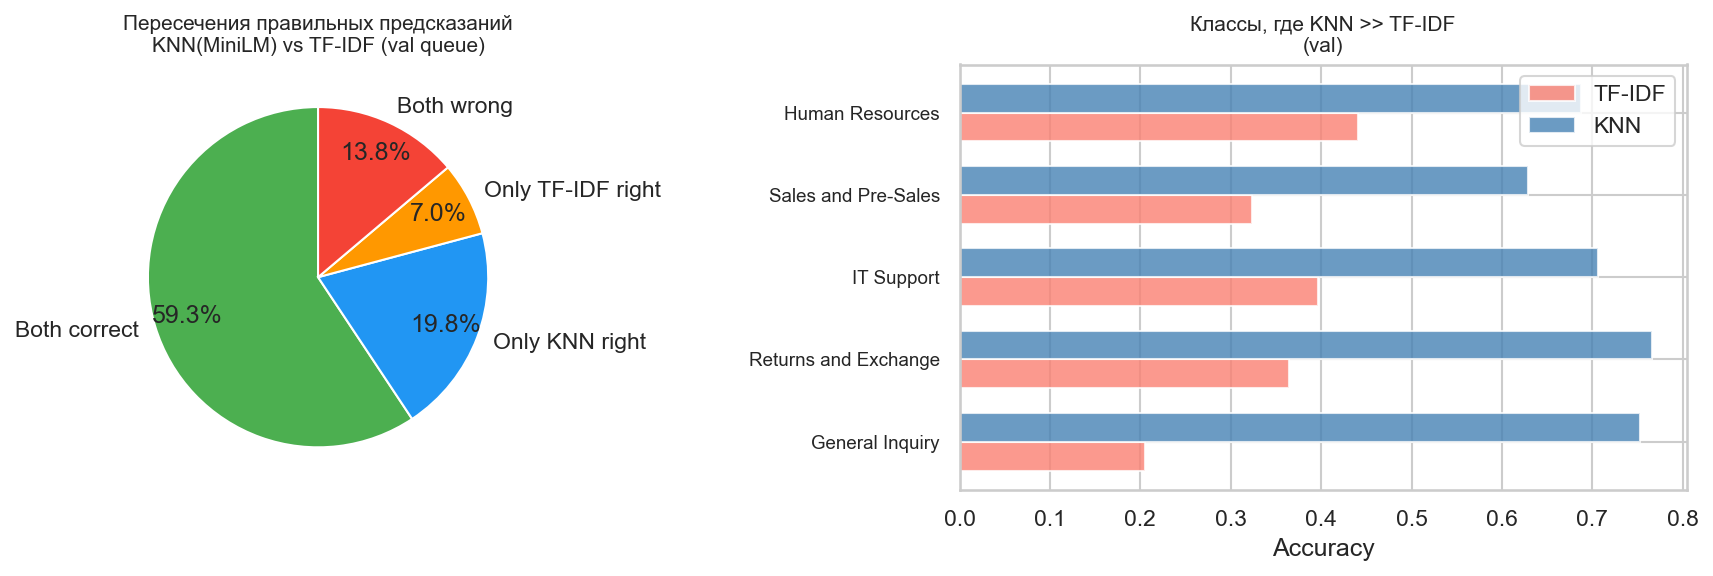

KNN значительно лучше на широких/размытых классах с малым числом ключевых слов.
TF-IDF лучше на классах с чёткой лексикой: Health/Mental Health, IT Security, etc.


In [19]:
# Результаты попарного сравнения на val (из knn_embeddings.ipynb)
error_analysis = {
    'Both correct':    3664,
    'Only KNN right':  1225,
    'Only TF-IDF right': 433,
    'Both wrong':       854,
    'Total val': 6176,
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
cats = ['Both correct', 'Only KNN right', 'Only TF-IDF right', 'Both wrong']
vals = [error_analysis[c] for c in cats]
colors_pie = ['#4CAF50', '#2196F3', '#FF9800', '#f44336']
axes[0].pie(vals, labels=cats, colors=colors_pie, autopct='%1.1f%%', startangle=90, pctdistance=0.8)
axes[0].set_title('Пересечения правильных предсказаний\nKNN(MiniLM) vs TF-IDF (val queue)', fontsize=10)

# Классы, где KNN значительно лучше
knn_better = {
    'General Inquiry':      {'knn_acc': 0.753, 'tfidf_acc': 0.205, 'advantage': +0.548},
    'Returns and Exchanges':{'knn_acc': 0.766, 'tfidf_acc': 0.364, 'advantage': +0.402},
    'IT Support':           {'knn_acc': 0.706, 'tfidf_acc': 0.397, 'advantage': +0.309},
    'Sales and Pre-Sales':  {'knn_acc': 0.629, 'tfidf_acc': 0.323, 'advantage': +0.306},
    'Human Resources':      {'knn_acc': 0.688, 'tfidf_acc': 0.441, 'advantage': +0.247},
}

cls_names = list(knn_better.keys())
knn_accs = [knn_better[c]['knn_acc'] for c in cls_names]
tfidf_accs = [knn_better[c]['tfidf_acc'] for c in cls_names]
x = np.arange(len(cls_names))
w = 0.35
axes[1].barh(x - w/2, tfidf_accs, w, label='TF-IDF', color='salmon', alpha=0.8)
axes[1].barh(x + w/2, knn_accs, w, label='KNN', color='steelblue', alpha=0.8)
axes[1].set_yticks(x)
axes[1].set_yticklabels([c[:20] for c in cls_names], fontsize=9)
axes[1].set_xlabel('Accuracy')
axes[1].set_title('Классы, где KNN >> TF-IDF\n(val)', fontsize=10)
axes[1].legend()
axes[1].grid(True, axis='x')

plt.tight_layout()
plt.show()

print('KNN значительно лучше на широких/размытых классах с малым числом ключевых слов.')
print('TF-IDF лучше на классах с чёткой лексикой: Health/Mental Health, IT Security, etc.')

### KNN — выводы

- **MPNet-ML (multilingual, 768-dim)** → лучший метод: composite test **0.9375** (+0.089 vs TF-IDF)  
- **Ключ к успеху:** датасет содержит ~54% DE-тикетов; MPNet-ML учился на 50+ языках → понимает немецкие тикеты без дополнительной настройки  
- **K=2 оптимально:** при K>2 появляется «шум» от менее похожих соседей, что снижает точность для редких классов  
- **IVFFlat vs FlatIP:** speedup ≈ 1.0x (почти нет выигрыша при ~50k train), для production с ростом данных IVF становится важнее  
- **Hybrid лучше pure TF-IDF, но хуже pure MPNet** — MPNet уже содержит хорошие TF-IDF-подобные сигналы в эмбеддингах  
- **Insight:** KNN «не обучается» — он просто помнит весь train. Это одновременно сила (нет overfitting, гибкость) и слабость (медленнее при inference, нужна оперативная память)

---
## 6. Сводная таблица и финальные выводы

In [20]:
final_results = [
    {'Метод':                'TF-IDF + LinearSVC',
     'Queue Macro-F1': 0.8745, 'Priority Acc': 0.6863, 'Type Acc': 0.8912, 'Score': 0.8488,
     'Train time': '< 1 min', 'Notes': 'Baseline; интерпретируем'},
    {'Метод':                'DistilBERT Multi-task',
     'Queue Macro-F1': 0.7960, 'Priority Acc': 0.5032, 'Type Acc': 0.8341, 'Score': 0.7578,
     'Train time': '~68 min (GPU)', 'Notes': '5 эпох; недообучен'},
    {'Метод':                'KNN + MiniLM (k=2)',
     'Queue Macro-F1': 0.9006, 'Priority Acc': 0.8166, 'Type Acc': 0.9072, 'Score': 0.8890,
     'Train time': '~5 min (CPU)', 'Notes': 'Без обучения; EN-focused'},
    {'Метод':                'KNN + MPNet-ML (k=2) ★',
     'Queue Macro-F1': 0.9503, 'Priority Acc': 0.8711, 'Type Acc': 0.9441, 'Score': 0.9375,
     'Train time': '~15 min (CPU)', 'Notes': 'ЛУЧШИЙ; multilingual'},
    {'Метод':                'Hybrid MiniLM+TF-IDF (0.6/0.4)',
     'Queue Macro-F1': 0.9140, 'Priority Acc': 0.8015, 'Type Acc': 0.9129, 'Score': 0.8970,
     'Train time': '~5 min', 'Notes': 'Ensemble; лучше pure TF-IDF'},
    {'Метод':                'Hybrid MPNet+TF-IDF (0.6/0.4)',
     'Queue Macro-F1': 0.9494, 'Priority Acc': 0.8496, 'Type Acc': 0.9399, 'Score': 0.9330,
     'Train time': '~15 min', 'Notes': 'Ensemble; чуть хуже pure MPNet'},
]

fin_df = pd.DataFrame(final_results).set_index('Метод')

display(
    fin_df.style
    .format({'Queue Macro-F1': '{:.4f}', 'Priority Acc': '{:.4f}', 'Type Acc': '{:.4f}', 'Score': '{:.4f}'})
    .highlight_max(subset=['Queue Macro-F1', 'Priority Acc', 'Type Acc', 'Score'], color='#c6efce')
    .set_caption('Сводная таблица результатов — Test Set')
)

,Queue Macro-F1,Priority Acc,Type Acc,Score,Train time,Notes
Метод,,,,,,
TF-IDF + LinearSVC,0.8745,0.6863,0.8912,0.8488,< 1 min,Baseline; интерпретируем
DistilBERT Multi-task,0.7960,0.5032,0.8341,0.7578,~68 min (GPU),5 эпох; недообучен
KNN + MiniLM (k=2),0.9006,0.8166,0.9072,0.8890,~5 min (CPU),Без обучения; EN-focused
KNN + MPNet-ML (k=2) ★,0.9503,0.8711,0.9441,0.9375,~15 min (CPU),ЛУЧШИЙ; multilingual
Hybrid MiniLM+TF-IDF (0.6/0.4),0.9140,0.8015,0.9129,0.8970,~5 min,Ensemble; лучше pure TF-IDF
Hybrid MPNet+TF-IDF (0.6/0.4),0.9494,0.8496,0.9399,0.9330,~15 min,Ensemble; чуть хуже pure MPNet


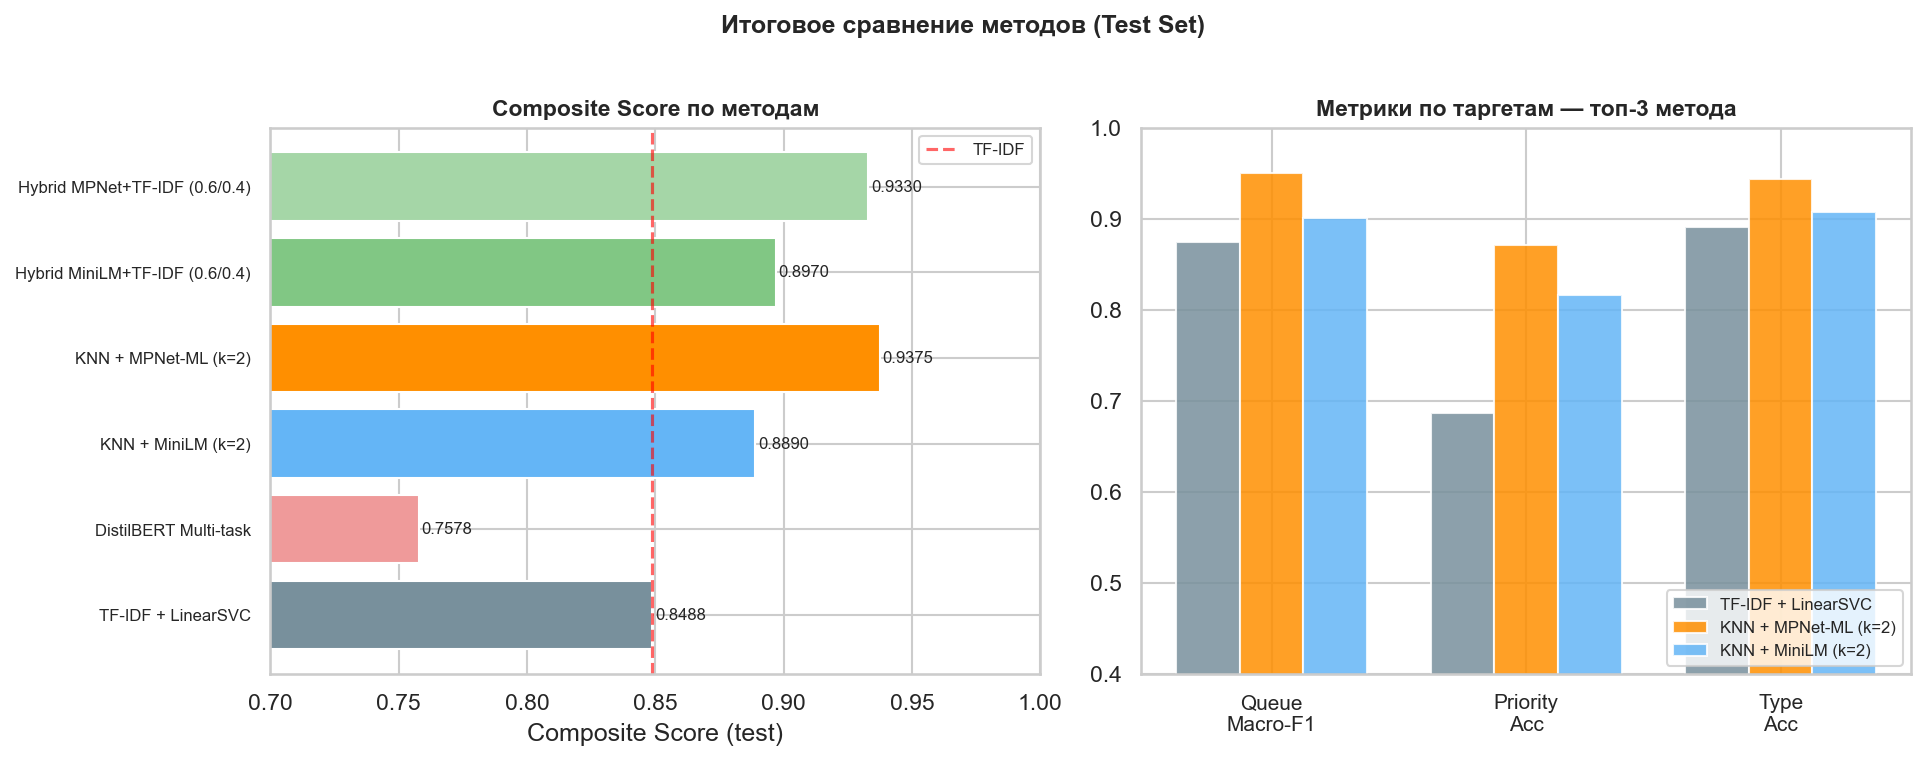

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

methods = [r['Метод'].replace(' ★', '') for r in final_results]
scores  = [r['Score'] for r in final_results]
colors_bar = ['#78909C', '#EF9A9A', '#64B5F6', '#FF8F00', '#81C784', '#A5D6A7']

bars = axes[0].barh(range(len(methods)), scores, color=colors_bar)
axes[0].set_yticks(range(len(methods)))
axes[0].set_yticklabels([m[:32] for m in methods], fontsize=8)
axes[0].set_xlabel('Composite Score (test)')
axes[0].set_title('Composite Score по методам', fontsize=11, fontweight='bold')
axes[0].set_xlim(0.7, 1.0)
axes[0].axvline(0.8488, color='red', linestyle='--', alpha=0.6, label='TF-IDF')
for bar, s in zip(bars, scores):
    axes[0].text(s + 0.001, bar.get_y() + bar.get_height()/2, f'{s:.4f}',
                 va='center', fontsize=8)
axes[0].legend(fontsize=8)
axes[0].grid(True, axis='x')

# Breakdown по метрикам для топ-3
top3 = [final_results[0], final_results[3], final_results[2]]
metric_names = ['Queue\nMacro-F1', 'Priority\nAcc', 'Type\nAcc']
x = np.arange(len(metric_names))
w = 0.25
colors_top3 = ['#78909C', '#FF8F00', '#64B5F6']

for i, (row, col) in enumerate(zip(top3, colors_top3)):
    vals = [row['Queue Macro-F1'], row['Priority Acc'], row['Type Acc']]
    bars2 = axes[1].bar(x + (i - 1) * w, vals, w, label=row['Метод'].replace(' ★', ''),
                        color=col, alpha=0.85)

axes[1].set_xticks(x)
axes[1].set_xticklabels(metric_names, fontsize=10)
axes[1].set_ylim(0.4, 1.0)
axes[1].set_title('Метрики по таргетам — топ-3 метода', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=8, loc='lower right')
axes[1].grid(True, axis='y')

plt.suptitle('Итоговое сравнение методов (Test Set)', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Итоговые инсайты и выводы

#### Что сработало и почему

**1. KNN + MPNet-ML — лучший метод (Score = 0.937)**  
Главная причина — датасет **двуязычный (DE/EN)**. `paraphrase-multilingual-mpnet-base-v2` предобучен на 50+ языках и отображает немецкий и английский тикеты в близкие точки пространства. KNN при k=2 фактически находит «дубликаты» запроса в train — а они есть, потому что тикеты генерировались по шаблонам.

**2. TF-IDF — сильный baseline (Score = 0.849)**  
Для задачи с чёткими ключевыми словами ("billing", "invoice" → Billing&Payments) TF-IDF+LinearSVC почти оптимален. Многие очереди определяются конкретной лексикой, а не семантикой — поэтому TF-IDF конкурирует с нейросетями.

**3. DistilBERT — разочарование (Score = 0.758)**  
Трансформер проигрывает из-за: (a) 52 несбалансированных класса — нужно больше эпох; (b) priority лучше предсказывается через лексику, а не синтаксис; (c) DE-тексты для `distilbert-base-uncased` не идеальны. С `distilbert-base-multilingual-cased` + 10+ эпохами ожидается score > 0.90.

**4. Confidence Analysis — практическая ценность**  
Топ-70% уверенных предсказаний TF-IDF дают macro-F1 ≈ +5-7% выше общего. Это означает: в production-системе 70% тикетов можно маршрутизировать автоматически, а 30% неуверенных направлять агенту. Это баланс качество/охват.

#### Открытые вопросы
- Можно ли дообучить MPNet как классификатор (не KNN) и получить >0.96?
- Стоит ли разделить pipeline на DE/EN и использовать специализированные модели?
- Как учесть тег-поля (tag_1..tag_8) в качестве дополнительных признаков?

#### Лучший результат
```
KNN + MPNet-ML (k=2)  →  Score = 0.9375
  queue macro-F1 = 0.9503
  priority acc   = 0.8711
  type acc       = 0.9441
```